# LeetCode #549: Binary Tree Longest Consecutive Sequence II

https://leetcode.com/problems/binary-tree-longest-consecutive-sequence-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (BFS + path re-scan)** | $O(n^2)$ | $O(n)$ |
| **Optimal: DFS Post-order ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Brute Force (BFS + path re-scan)
Enumerate every node and walk up/down looking for consecutive chains. Each walk is $O(n)$, leading to $O(n^2)$ overall — too slow for large trees.

### Optimal: DFS Post-order ★
Post-order DFS returns `(inc, dec)` for each subtree: the longest increasing (child < parent) and decreasing (child > parent) chains through that node. The answer at each node is `inc + dec - 1`; take the global max.

**Why this is better than Brute Force:** Single pass — each node visited exactly once; no redundant path retraversal.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 3 \times 10^4]$.
* $-3 \times 10^4 \le$ Node.val $\le 3 \times 10^4$

## Solutions

### C#

In [ ]:
public int LongestConsecutive(TreeNode root) {
    int maxLen = 0;
    // Post-order: return (longest increasing seq, longest decreasing seq) through node
    (int inc, int dec) Dfs(TreeNode node) {
        if (node == null) return (0, 0);
        var (li, ld) = Dfs(node.left);
        var (ri, rd) = Dfs(node.right);
        int inc = 1, dec = 1;
        // Extend inc/dec chains from left child
        if (node.left != null) {
            if (node.val == node.left.val + 1) dec = Math.Max(dec, ld + 1);
            if (node.val == node.left.val - 1) inc = Math.Max(inc, li + 1);
        }
        // Extend inc/dec chains from right child
        if (node.right != null) {
            if (node.val == node.right.val + 1) dec = Math.Max(dec, rd + 1);
            if (node.val == node.right.val - 1) inc = Math.Max(inc, ri + 1);
        }
        // Chain through this node: longest path that bends here
        maxLen = Math.Max(maxLen, inc + dec - 1);
        return (inc, dec);
    }
    Dfs(root);
    return maxLen;
}

### Python

In [ ]:
def longestConsecutive(self, root: Optional[TreeNode]) -> int:
    self.max_len = 0

    def dfs(node):
        if not node:
            return 0, 0
        li, ld = dfs(node.left)
        ri, rd = dfs(node.right)
        inc = dec = 1
        # Extend chains from left child
        if node.left:
            if node.val == node.left.val + 1:
                dec = max(dec, ld + 1)
            if node.val == node.left.val - 1:
                inc = max(inc, li + 1)
        # Extend chains from right child
        if node.right:
            if node.val == node.right.val + 1:
                dec = max(dec, rd + 1)
            if node.val == node.right.val - 1:
                inc = max(inc, ri + 1)
        # Update global max: chain bends at current node
        self.max_len = max(self.max_len, inc + dec - 1)
        return inc, dec

    dfs(root)
    return self.max_len

### Go

In [ ]:
func longestConsecutive(root *TreeNode) int {
    maxLen := 0
    // Post-order: returns (longest increasing seq, longest decreasing seq)
    var dfs func(*TreeNode) (int, int)
    dfs = func(node *TreeNode) (int, int) {
        if node == nil {
            return 0, 0
        }
        li, ld := dfs(node.Left)
        ri, rd := dfs(node.Right)
        inc, dec := 1, 1
        // Extend chains from left child
        if node.Left != nil {
            if node.Val == node.Left.Val+1 && ld+1 > dec { dec = ld + 1 }
            if node.Val == node.Left.Val-1 && li+1 > inc { inc = li + 1 }
        }
        // Extend chains from right child
        if node.Right != nil {
            if node.Val == node.Right.Val+1 && rd+1 > dec { dec = rd + 1 }
            if node.Val == node.Right.Val-1 && ri+1 > inc { inc = ri + 1 }
        }
        // Update global max: chain through this node
        if inc+dec-1 > maxLen { maxLen = inc + dec - 1 }
        return inc, dec
    }
    dfs(root)
    return maxLen
}

### Rust

In [ ]:
pub fn longest_consecutive(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
    let mut max_len = 0i32;
    // Post-order: returns (longest inc chain, longest dec chain)
    fn dfs(node: &Option<Rc<RefCell<TreeNode>>>, max_len: &mut i32) -> (i32, i32) {
        let n = match node { None => return (0, 0), Some(n) => n.borrow() };
        let (li, ld) = dfs(&n.left, max_len);
        let (ri, rd) = dfs(&n.right, max_len);
        let (mut inc, mut dec) = (1i32, 1i32);
        // Extend chains from left child
        if let Some(l) = &n.left {
            let lv = l.borrow().val;
            if n.val == lv + 1 { dec = dec.max(ld + 1); }
            if n.val == lv - 1 { inc = inc.max(li + 1); }
        }
        // Extend chains from right child
        if let Some(r) = &n.right {
            let rv = r.borrow().val;
            if n.val == rv + 1 { dec = dec.max(rd + 1); }
            if n.val == rv - 1 { inc = inc.max(ri + 1); }
        }
        // Update global max: chain bends at current node
        *max_len = (*max_len).max(inc + dec - 1);
        (inc, dec)
    }
    dfs(&root, &mut max_len);
    max_len
}

## Example Scenarios

**1. Common Case**
**Input:** root = [1,2,3] (1 at root, 2 left, 3 right)
Dfs(2)→(1,1), Dfs(3)→(1,1). At root 1: left child 2 = 1+1 so inc=2; right child 3 = 1+1 from root... wait root=1, right=3 not consecutive. So inc=2 (1→2), dec=1. maxLen = 2+1-1 = 2. Returns 2.

**2. Slightly Complex**
**Input:** root = [2,1,3] (2 at root, 1 left, 3 right)
Dfs(1)→(1,1), Dfs(3)→(1,1). At root 2: left child 1 = 2-1 so dec=2; right child 3 = 2+1 so inc=2. maxLen = 2+2-1 = **3** (path 1←2→3). Optimal path uses the bend.

**3. Edge Case: Time Factor**
**Input:** A right-skewed chain [1,null,2,null,3,...,n]
The DFS recurses all the way to the deepest node before returning. With $n = 3 \times 10^4$ nodes, call stack depth equals $n$, exercising the worst-case $O(h) = O(n)$ space on the stack.

**4. Edge Case: Space Factor**
**Input:** A perfectly balanced tree with $n \approx 3 \times 10^4$ nodes
Stack depth $h = O(\log n) \approx 15$. No long consecutive sequences exist (random values), so maxLen stays 1. The recursion is shallow but every node is visited — best-case space $O(\log n)$.

**5. Almost-Impossible but Plausible**
**Input:** A V-shaped tree: left chain $[10, 9, 8, 7]$ and right chain $[10, 11, 12, 13]$ rooted at 10
At root 10: dec-chain through left = 4, inc-chain through right = 4. Combined path = 4+4-1 = **7**. Values span $[7..13]$ — the single root acts as pivot for both directions simultaneously.

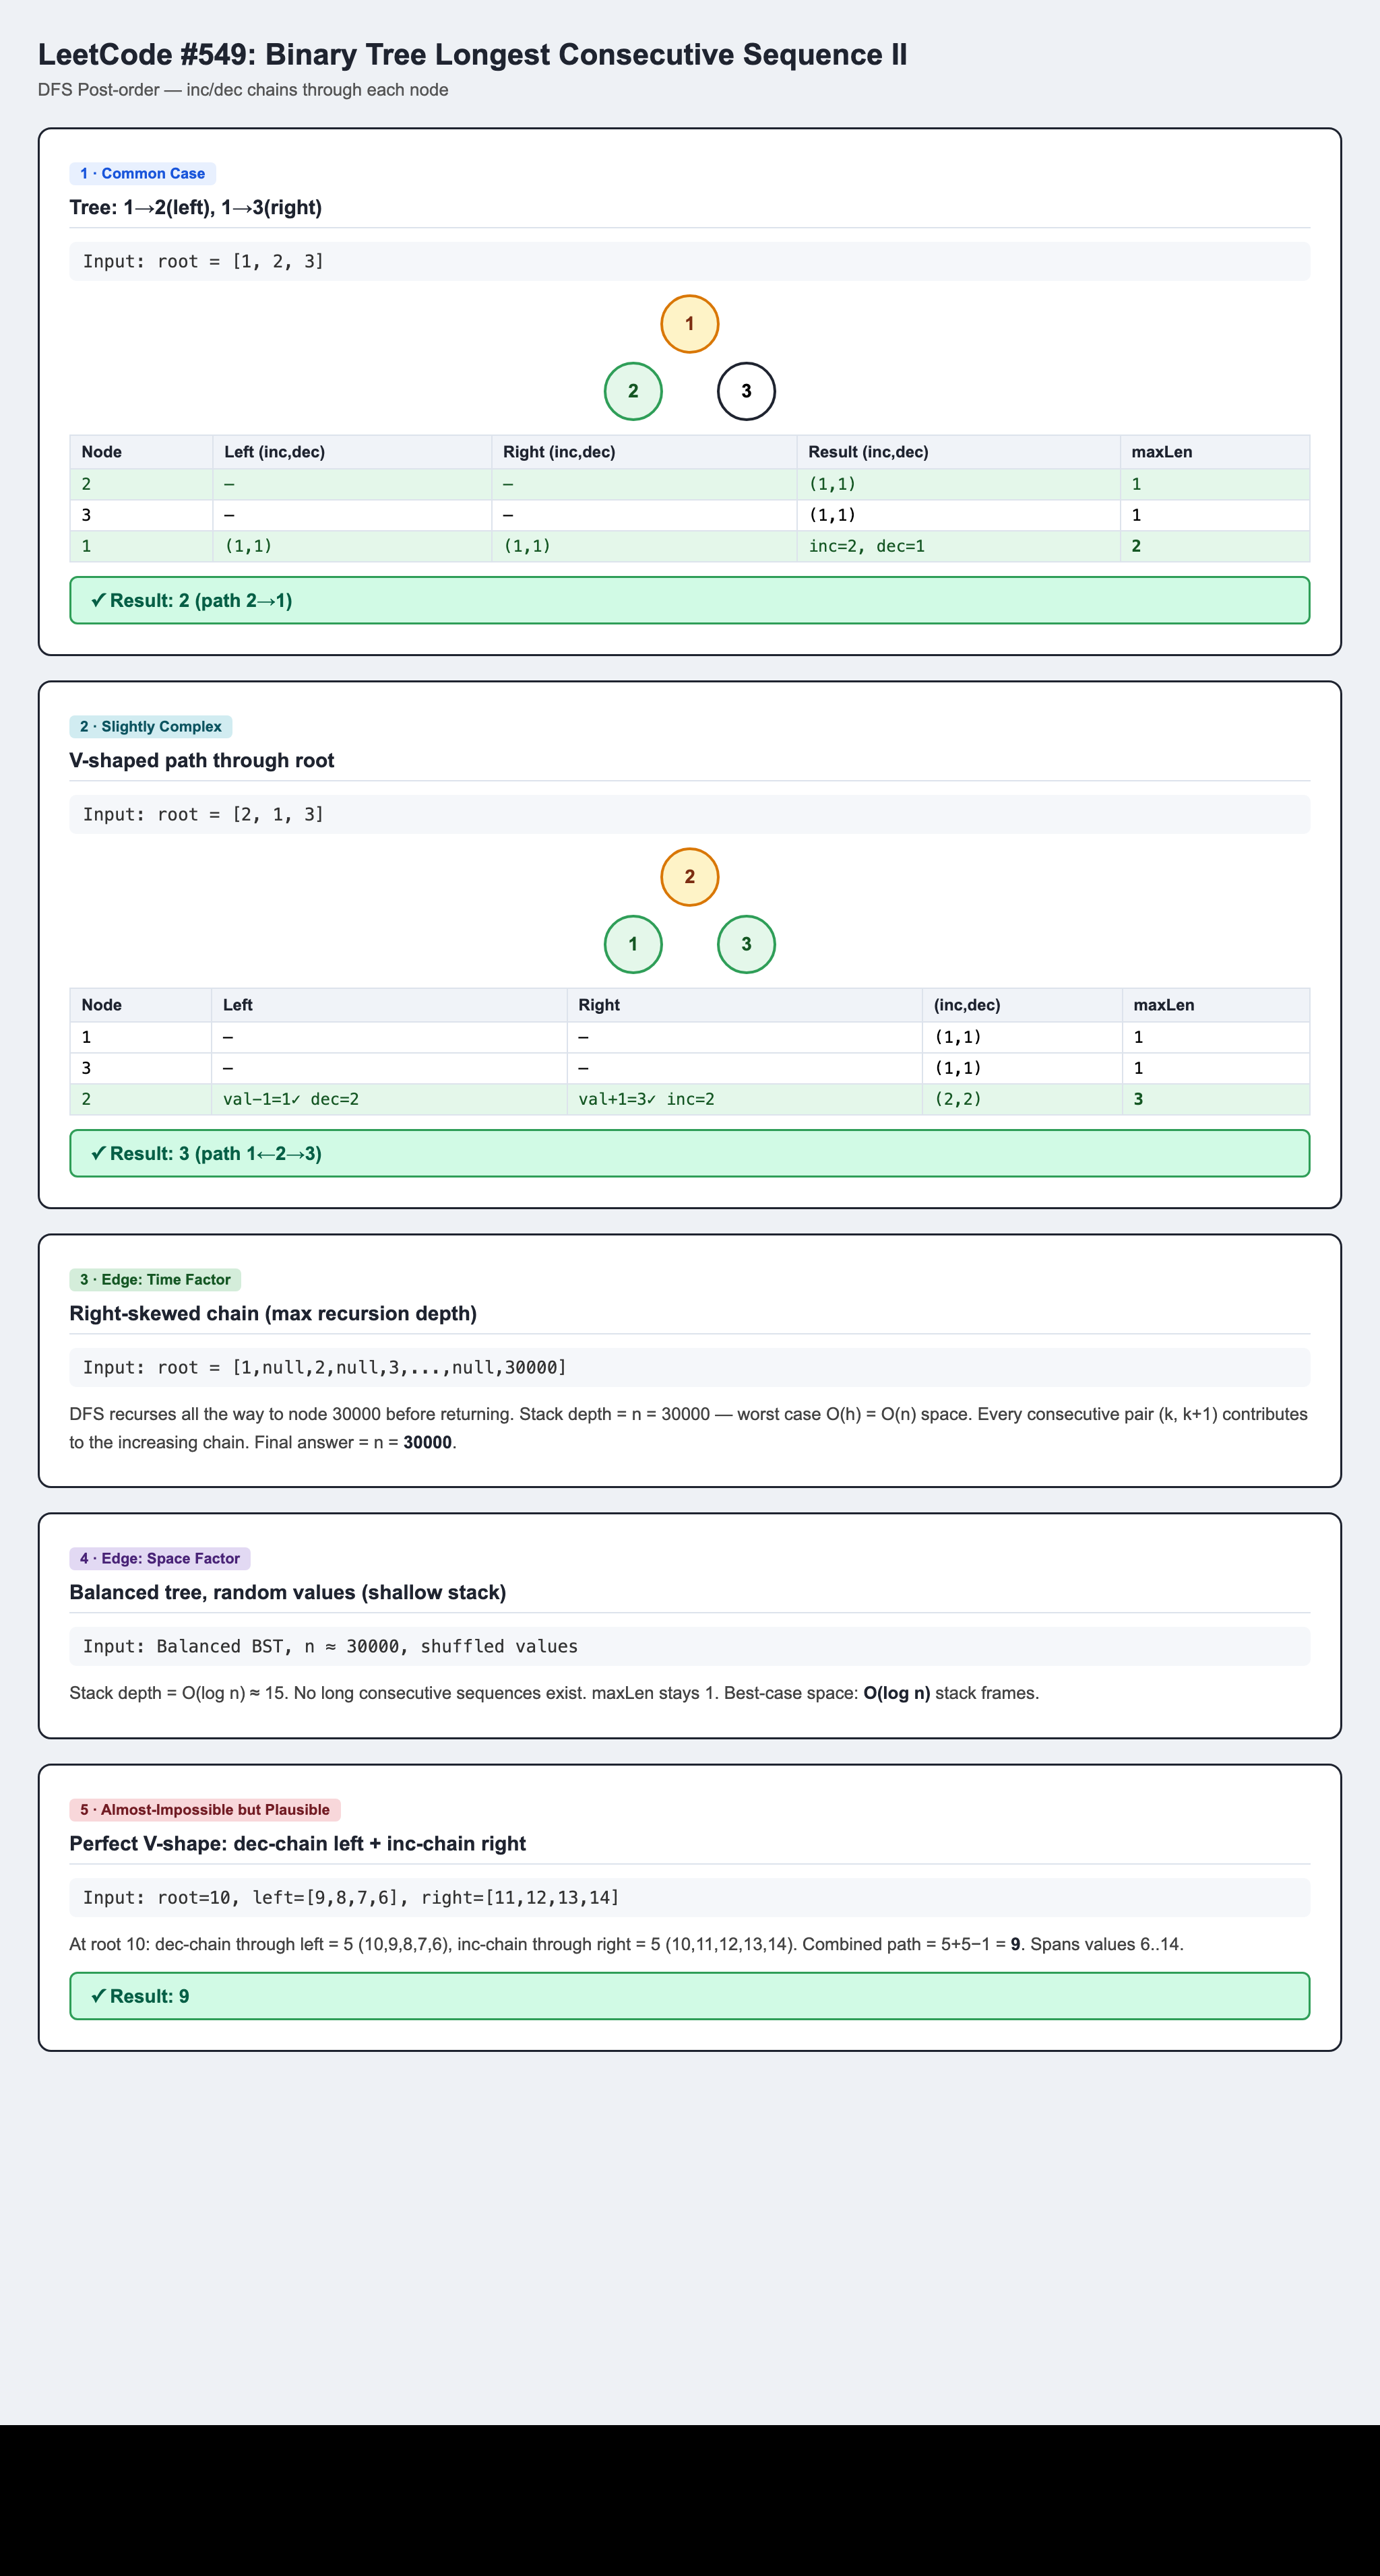